# Classical baseline experiments
The same runner handles CLI and notebook experiments. Every fitting call creates a new logged run.

In [1]:
from pathlib import Path
import os
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
import json
import pandas as pd
from IPython.display import display, Image
from m6a_project.training import load_config, run_experiment
from m6a_project.tracking import rebuild_index
from m6a_project.cache import prepare_data
CONFIG = load_config("configs/experiments/baselines_v1.toml")


In [2]:
# Enable deliberately to create a new experiment; normal replay only reads saved results.
RUN_NEW_EXPERIMENT = False
if RUN_NEW_EXPERIMENT:
    config = dict(CONFIG)
    config["experiment_set"] = "notebook_exploration"
    config["notebook_source"] = "notebooks/02_classical_comparison.ipynb"
    config["purpose"] = "Explore a documented variant using the frozen data0 split"
    run_experiment(config, approach="read9_noisy_or", model="logistic")

In [3]:
index = rebuild_index()
complete = index.query("experiment_set == 'data0_baselines_v1' and status == 'completed'")
display(complete[["approach", "model", "average_precision", "roc_auc", "pr_auc_trapezoid", "brier_score", "fit_seconds"]])

,approach,model,average_precision,roc_auc,pr_auc_trapezoid,brier_score,fit_seconds
0,site_mean9,dummy,0.043511,0.500000,0.521755,0.041621,0.001808
1,site_mean9,logistic,0.099416,0.707058,0.098744,0.040571,0.055276
2,read9_noisy_or,logistic,0.070899,0.693366,0.070737,0.332252,1.345597
3,read15_noisy_or,logistic,0.146598,0.775981,0.146083,0.294377,2.842505
4,site_mean9,hist_boosting,0.394808,0.864127,0.394321,0.032065,2.816759
5,read9_noisy_or,hist_boosting,0.337521,0.860411,0.336621,0.271313,9.119751
6,read15_noisy_or,hist_boosting,0.379881,0.878190,0.379341,0.237489,17.033117
7,site_mean9,random_forest,0.364940,0.858864,0.363981,0.033298,3.525346
8,read9_noisy_or,random_forest,0.328180,0.853769,0.327293,0.284619,46.322071
9,read15_noisy_or,random_forest,0.328841,0.865362,0.328197,0.253001,34.353831


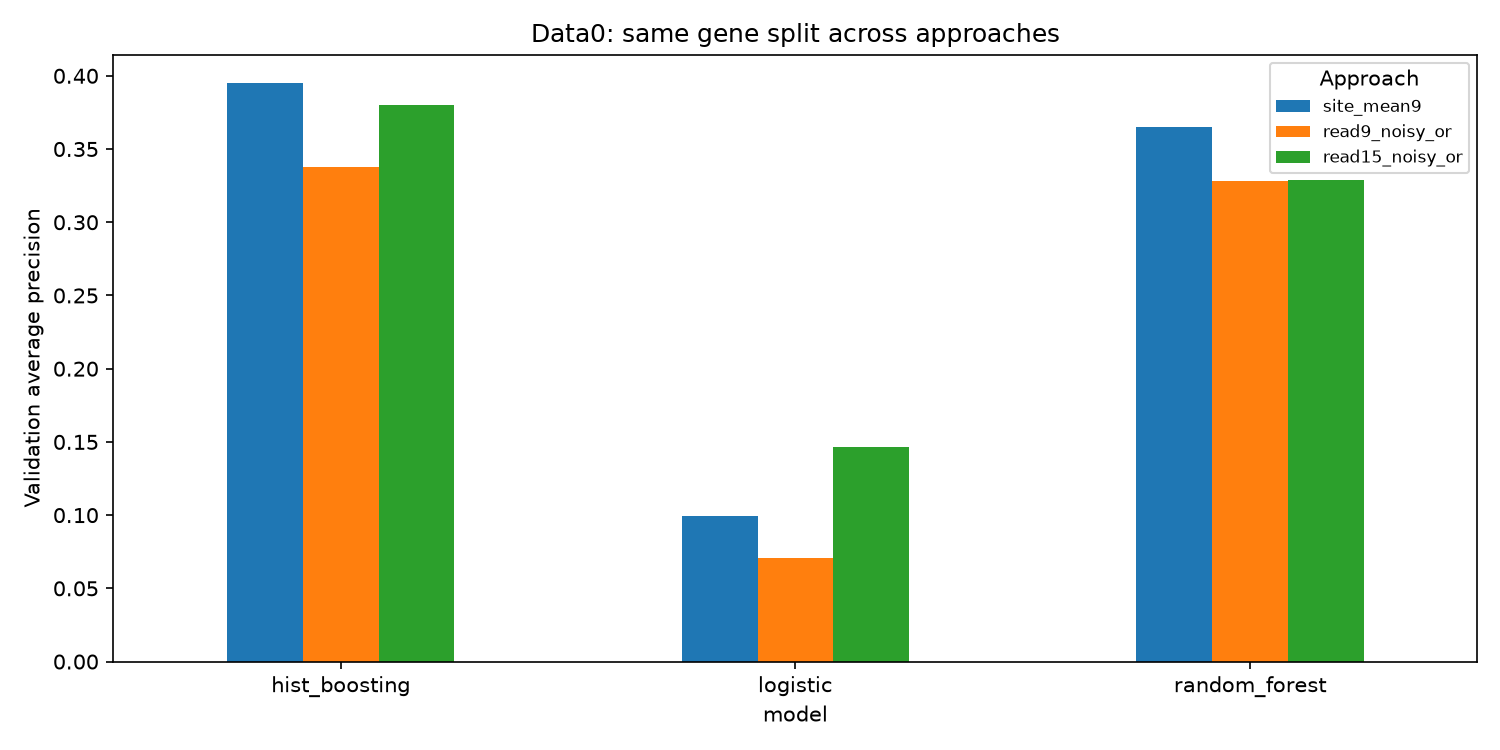

,model,A2_minus_A1_AP,A3_minus_A2_AP
0,hist_boosting,-0.057287,0.042360
1,logistic,-0.028517,0.075699
2,random_forest,-0.036760,0.000661


In [4]:
display(Image(filename="docs/results/comparison.png"))
display(pd.read_csv("docs/results/approach_differences.csv"))

Compare approaches within each classifier. Better performance from A1 to A3 is a hypothesis, not a requirement. The matched-mean control uses the same read samples as A2/A3. Validation has been used for model selection and is not an independent test.